# RAG Evaluation Notebook
### Text enriched retrieval text vs original single-field retrieval.
### Evaluates both retrieval quality (majority vote) and LLM classification accuracy.

Load data and model

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sentence_transformers import SentenceTransformer

df = pd.read_parquet("data/processed/cfr_savings_processed.parquet")
print(f"Rows: {len(df)} | Columns: {len(df.columns)}")

# filter to NAM market
df_nam = df[df["market"] == "NAM"].copy()
print(f"NAM rows: {len(df_nam)}")

# load embedding model
embedding_model = SentenceTransformer("models/bge-base-en-v1.5")

# load taxonomy
from src.classification.taxonomy import load_taxonomy, format_taxonomy_for_prompt
taxonomy = load_taxonomy("data/raw/nam_label.xlsx")
taxonomy_text = format_taxonomy_for_prompt(taxonomy)

c:\Users\320305732\AppData\Local\miniforge3\envs\call_classification\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rows: 13194 | Columns: 122
NAM rows: 2310


'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)' thrown while requesting HEAD https://huggingface.co/models/bge-base-en-v1.5/resolve/main/./README.md
Retrying in 1s [Retry 1/5].
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4072.06it/s]
BertModel LOAD REPORT from: models/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Enriched text builders

In [2]:
def build_retrieval_text(row):
    """
    Build enriched text for retrieval (embedding + BM25).

    Concatenates extracted fields with markers.
    Includes: problem_description, error, malfunction_area, diagnostic.
    Skips repair_action (describes fix, not problem — causes cross-category noise).
    Only includes fields that are non-null.
    """
    parts = []

    # problem description is the base — always include if available
    pd_text = row.get("extracted_problem_description_remote")
    if pd.notna(pd_text) and str(pd_text).strip():
        parts.append(str(pd_text).strip())

    # error codes — rare (22%) but highly distinctive
    error = row.get("extracted_error_remote")
    if pd.notna(error) and str(error).strip():
        parts.append(f"ERROR: {str(error).strip()}")

    # malfunction area — component names
    area = row.get("extracted_malfunction_area_remote")
    if pd.notna(area) and str(area).strip():
        parts.append(f"AREA: {str(area).strip()}")

    # diagnostic — what was found (75% fill, strong signal)
    diag = row.get("extracted_diagnostic_remote")
    if pd.notna(diag) and str(diag).strip():
        parts.append(f"DIAGNOSTIC: {str(diag).strip()}")

    return " [SEP] ".join(parts) if parts else None


def build_llm_context(row):
    """
    Build rich context text for the LLM prompt.

    Uses raw remote_remarks_en for maximum completeness.
    Falls back to concatenated extracted fields if raw text is missing.
    """
    # prefer raw text — the LLM can handle boilerplate
    raw = row.get("remote_remarks_en")
    if pd.notna(raw) and len(str(raw).strip()) > 20:
        return str(raw).strip()

    # fallback: structured extracted fields
    parts = []
    fields = [
        ("Problem", "extracted_problem_description_remote"),
        ("Error", "extracted_error_remote"),
        ("Area", "extracted_malfunction_area_remote"),
        ("Diagnostic", "extracted_diagnostic_remote"),
        ("Repair action", "extracted_repair_action_remote"),
    ]
    for label, col in fields:
        val = row.get(col)
        if pd.notna(val) and str(val).strip():
            parts.append(f"{label}: {str(val).strip()}")

    return "\n".join(parts) if parts else None

Build enriched columns

In [3]:
# retrieval text (for embedding + BM25)
df_nam["retrieval_text_enriched"] = df_nam.apply(build_retrieval_text, axis=1)

# LLM context text (for showing in prompts)
df_nam["llm_context_text"] = df_nam.apply(build_llm_context, axis=1)

# check fill rates
print("ENRICHED TEXT FILL RATES")
print("-" * 50)
for col in ["extracted_problem_description_remote", "retrieval_text_enriched", "llm_context_text"]:
    filled = df_nam[col].notna().sum()
    print(f"  {col:<45} {filled}/{len(df_nam)} ({filled/len(df_nam):.0%})")

# show a sample to verify
print("\n── SAMPLE COMPARISON ──")
sample = df_nam[df_nam["retrieval_text_enriched"].notna()].iloc[0]
print(f"\nORIGINAL (problem_description only):")
print(f"  {sample['extracted_problem_description_remote'][:200]}")
print(f"\nENRICHED RETRIEVAL TEXT:")
print(f"  {sample['retrieval_text_enriched'][:300]}")
print(f"\nLLM CONTEXT (first 300 chars):")
print(f"  {str(sample['llm_context_text'])[:300]}")


ENRICHED TEXT FILL RATES
--------------------------------------------------
  extracted_problem_description_remote          1803/2310 (78%)
  retrieval_text_enriched                       1803/2310 (78%)
  llm_context_text                              2021/2310 (87%)

── SAMPLE COMPARISON ──

ORIGINAL (problem_description only):
  Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the breakers,  No PRS connection, Remote password is not s

ENRICHED RETRIEVAL TEXT:
  Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the breakers,  No PRS connection, Remote password is not set, [SEP] DIAGNOSTIC: No PRS connection, Remote password is not set,
Confirm host power cycle,
Confi

LLM CONTEXT (first 300 chars):
  *** Diagnostic performed by Engineer [2025-12-19 16:54:53]
No PRS connection, Remote password is not se

Filter labeled cases, split, build indices

In [5]:
from src.classification.evaluation import split_labeled_data, evaluate_retrieval
from src.classification.retriever import build_index, retrieve_batch

# filter to labeled cases — need BOTH retrieval texts to be non-null for fair comparison
nam_labeled = df_nam[
    df_nam["nam_main_category"].notna() &
    df_nam["extracted_problem_description_remote"].notna() &
    df_nam["retrieval_text_enriched"].notna()
].copy()
print(f"Labeled cases with both texts: {len(nam_labeled)}")

# split: 80% index, 20% test
index_df, test_df = split_labeled_data(nam_labeled, test_size=0.2)

# build ORIGINAL index (problem_description only)
print("\n── Building ORIGINAL index ──")
index_original = build_index(
    index_df,
    text_col="extracted_problem_description_remote",
    label_cols=["nam_main_category", "nam_sub_category"],
    embedding_model=embedding_model,
)

# build ENRICHED index (concatenated fields)
print("\n── Building ENRICHED index ──")
index_enriched = build_index(
    index_df,
    text_col="retrieval_text_enriched",
    label_cols=["nam_main_category", "nam_sub_category"],
    embedding_model=embedding_model,
)

Labeled cases with both texts: 1607
  Split: 1285 index / 322 test (80% / 20%)

── Building ORIGINAL index ──
  Embedding 1282 labeled cases...


Batches: 100%|██████████| 41/41 [03:38<00:00,  5.32s/it]


  Index built: 1282 cases, 768 dense dims + BM25 sparse

── Building ENRICHED index ──
  Embedding 1282 labeled cases...


Batches: 100%|██████████| 41/41 [09:03<00:00, 13.26s/it]


  Index built: 1282 cases, 768 dense dims + BM25 sparse


-------------------------------


Retrieve label distribution

In [4]:
# %% Category distribution — full labeled set (before any split)

import matplotlib.pyplot as plt

# main category distribution
print("MAIN CATEGORY DISTRIBUTION")
print("-" * 50)
main_counts = nam_labeled["nam_main_category"].value_counts()
total = len(nam_labeled)

print(f"{'Category':<25} {'Count':>6} {'%':>7}")
print("-" * 40)
for cat, count in main_counts.items():
    print(f"  {cat:<23} {count:>6} {count/total:>6.1%}")
print(f"\n  {'TOTAL':<23} {total:>6}")

# bar chart
fig, ax = plt.subplots(figsize=(12, 6))
main_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of cases")
ax.set_title(f"Main Category Distribution (n={total})")
ax.invert_yaxis()
for i, (count) in enumerate(main_counts):
    ax.text(count + 5, i, f"{count} ({count/total:.1%})", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/reports/category_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# sub category distribution
print(f"\n\nSUB CATEGORY DISTRIBUTION (top 30)")
print("-" * 50)
sub_counts = nam_labeled["nam_sub_category"].value_counts()
print(f"{'Sub Category':<30} {'Main Category':<25} {'Count':>6}")
print("-" * 65)
for sub, count in sub_counts.head(30).items():
    # find which main category this sub belongs to
    main = nam_labeled[nam_labeled["nam_sub_category"] == sub]["nam_main_category"].mode().iloc[0]
    print(f"  {sub:<28} {main:<23} {count:>6}")
print(f"\n  Unique sub categories: {nam_labeled['nam_sub_category'].nunique()}")

MAIN CATEGORY DISTRIBUTION
--------------------------------------------------


NameError: name 'nam_labeled' is not defined

retrieve token distribution


Problem description only
--------------------------------------------------
  Count:    1607
  Mean:     16 words
  Median:   8 words
  Std:      38 words
  Min:      1 words
  Max:      1312 words
  P25:      6 words
  P75:      15 words
  P95:      49 words
  P99:      105 words
  Est. tokens (×1.3): mean≈20, P95≈63, max≈1706

Enriched retrieval text
--------------------------------------------------
  Count:    1607
  Mean:     74 words
  Median:   54 words
  Std:      90 words
  Min:      2 words
  Max:      2638 words
  P25:      30 words
  P75:      90 words
  P95:      199 words
  P99:      304 words
  Est. tokens (×1.3): mean≈96, P95≈259, max≈3429

LLM context (raw remarks)
--------------------------------------------------
  Count:    1607
  Mean:     323 words
  Median:   263 words
  Std:      278 words
  Min:      60 words
  Max:      4048 words
  P25:      184 words
  P75:      380 words
  P95:      670 words
  P99:      1078 words
  Est. tokens (×1.3): mean≈420, P95≈871, 

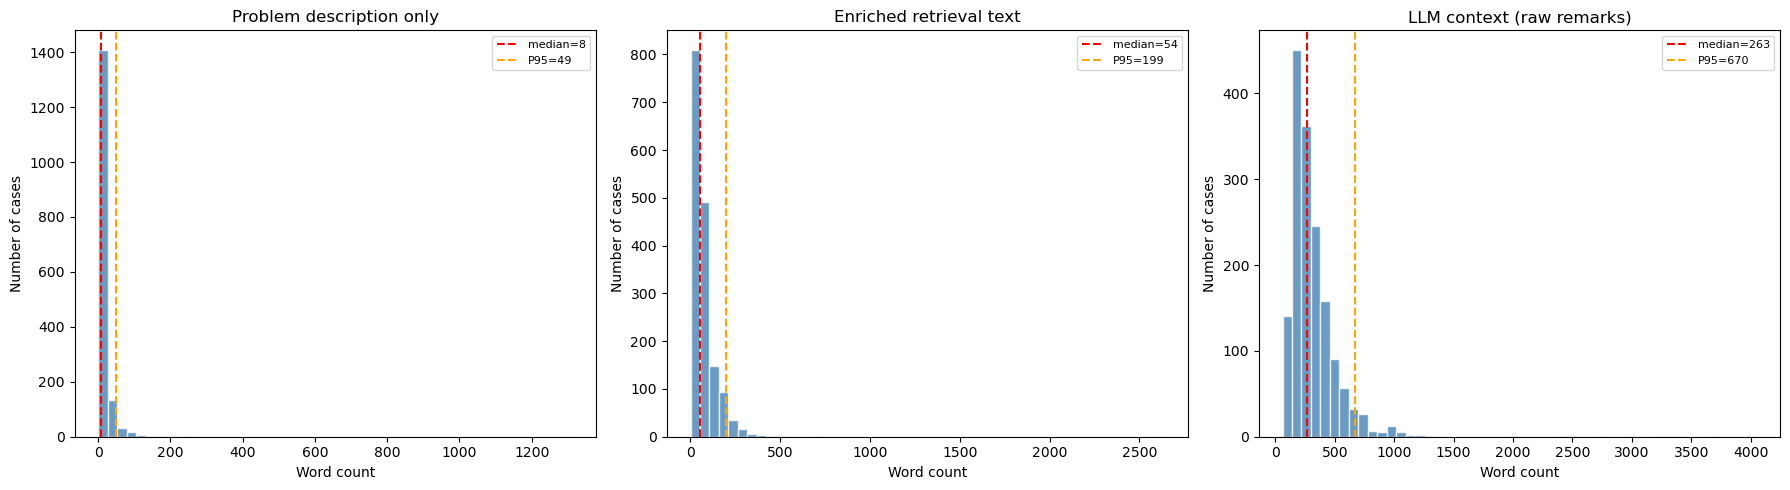



PROMPT SIZE ESTIMATION (n=10 examples)
--------------------------------------------------
  Taxonomy:          ~305 words
  10 examples:       ~540 words (10 × 54)
  Case context:      ~263 words
  Instructions:      ~50 words
  Total est.:        ~1158 words ≈ 1505 tokens


In [6]:
# %% Token length distribution — enriched texts

import matplotlib.pyplot as plt
import numpy as np

# simple whitespace tokenization (approximation — LLM tokenizers vary
# but word count is a reasonable proxy, ~1.3 tokens per word for English)
def token_stats(series, name):
    lengths = series.dropna().apply(lambda x: len(str(x).split()))
    print(f"\n{name}")
    print("-" * 50)
    print(f"  Count:    {len(lengths)}")
    print(f"  Mean:     {lengths.mean():.0f} words")
    print(f"  Median:   {lengths.median():.0f} words")
    print(f"  Std:      {lengths.std():.0f} words")
    print(f"  Min:      {lengths.min()} words")
    print(f"  Max:      {lengths.max()} words")
    print(f"  P25:      {lengths.quantile(0.25):.0f} words")
    print(f"  P75:      {lengths.quantile(0.75):.0f} words")
    print(f"  P95:      {lengths.quantile(0.95):.0f} words")
    print(f"  P99:      {lengths.quantile(0.99):.0f} words")
    print(f"  Est. tokens (×1.3): mean≈{lengths.mean()*1.3:.0f}, "
          f"P95≈{lengths.quantile(0.95)*1.3:.0f}, "
          f"max≈{lengths.max()*1.3:.0f}")
    return lengths

fields = {
    "Problem description only": nam_labeled["extracted_problem_description_remote"],
    "Enriched retrieval text": nam_labeled["retrieval_text_enriched"],
    "LLM context (raw remarks)": nam_labeled["llm_context_text"],
}

all_lengths = {}
for name, series in fields.items():
    all_lengths[name] = token_stats(series, name)

# histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, lengths) in zip(axes, all_lengths.items()):
    ax.hist(lengths, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(lengths.median(), color="red", linestyle="--", label=f"median={lengths.median():.0f}")
    ax.axvline(lengths.quantile(0.95), color="orange", linestyle="--", label=f"P95={lengths.quantile(0.95):.0f}")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Number of cases")
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("data/reports/token_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# prompt size estimation (n=10 examples)
print("\n\nPROMPT SIZE ESTIMATION (n=10 examples)")
print("-" * 50)
enriched_median = all_lengths["Enriched retrieval text"].median()
context_median = all_lengths["LLM context (raw remarks)"].median()
taxonomy_words = len(taxonomy_text.split())

prompt_words = (
    taxonomy_words +              # taxonomy
    10 * enriched_median +        # 10 retrieved examples
    context_median +              # case context
    50                            # instructions
)
print(f"  Taxonomy:          ~{taxonomy_words} words")
print(f"  10 examples:       ~{10 * enriched_median:.0f} words (10 × {enriched_median:.0f})")
print(f"  Case context:      ~{context_median:.0f} words")
print(f"  Instructions:      ~50 words")
print(f"  Total est.:        ~{prompt_words:.0f} words ≈ {prompt_words*1.3:.0f} tokens")

-----------------------------------

Retrieve and evaluate: original vs enriched

In [5]:
# original retrieval
test_texts_original = test_df["extracted_problem_description_remote"].tolist()
examples_original = retrieve_batch(test_texts_original, index_original, embedding_model, n=5)
results_original = evaluate_retrieval(
    test_df, examples_original,
    "extracted_problem_description_remote", "nam_main_category",
)

# enriched retrieval
test_texts_enriched = test_df["retrieval_text_enriched"].tolist()
examples_enriched = retrieve_batch(test_texts_enriched, index_enriched, embedding_model, n=12)
results_enriched = evaluate_retrieval(
    test_df, examples_enriched,
    "retrieval_text_enriched", "nam_main_category",
)

# side-by-side comparison
print(f"\n{'Metric':<30} {'Original':>10} {'Enriched':>10} {'Delta':>8}")
print("-" * 62)
for metric, label in [
    ("majority_accuracy", "Majority vote accuracy"),
    ("any_correct_rate", "Any correct in top-5"),
    ("avg_top1_similarity", "Avg top-1 similarity"),
]:
    orig = results_original[metric]
    enr = results_enriched[metric]
    delta = enr - orig
    sign = "+" if delta > 0 else ""
    if metric == "avg_top1_similarity":
        print(f"  {label:<28} {orig:>9.3f} {enr:>9.3f} {sign}{delta:>7.3f}")
    else:
        print(f"  {label:<28} {orig:>9.1%} {enr:>9.1%} {sign}{delta:>6.1%}")

Batches: 100%|██████████| 11/11 [00:58<00:00,  5.36s/it]



Metric                           Original   Enriched    Delta
--------------------------------------------------------------
  Majority vote accuracy           62.4%     70.5% +  8.1%
  Any correct in top-5             80.7%     92.9% + 12.1%
  Avg top-1 similarity             0.835     0.846 +  0.010


Per-category retrieval comparison

In [6]:
true_labels = test_df["nam_main_category"].tolist()

def category_accuracy(all_examples, true_labels):
    """Compute majority-vote accuracy per category."""
    stats = {}
    for true_label, examples in zip(true_labels, all_examples):
        labels = [ex["labels"]["nam_main_category"] for ex in examples]
        majority = Counter(labels).most_common(1)[0][0]
        if true_label not in stats:
            stats[true_label] = {"total": 0, "correct": 0}
        stats[true_label]["total"] += 1
        if majority == true_label:
            stats[true_label]["correct"] += 1
    return stats

orig_stats = category_accuracy(examples_original, true_labels)
enr_stats = category_accuracy(examples_enriched, true_labels)

print(f"\n{'Category':<25} {'Orig':>8} {'Enriched':>10} {'Delta':>8} {'Support':>8}")
print("-" * 63)
for cat in sorted(orig_stats.keys(), key=lambda c: orig_stats[c]["correct"]/max(orig_stats[c]["total"],1)):
    o = orig_stats[cat]
    e = enr_stats.get(cat, {"correct": 0, "total": o["total"]})
    o_acc = o["correct"] / o["total"]
    e_acc = e["correct"] / e["total"]
    delta = e_acc - o_acc
    sign = "+" if delta > 0 else ""
    print(f"  {cat:<23} {o_acc:>7.0%} {e_acc:>9.0%} {sign}{delta:>7.0%} {o['total']:>7}")


Category                      Orig   Enriched    Delta  Support
---------------------------------------------------------------
  system_related_parts         0%        0%      0%       1
  physiology                   0%        0%      0%       3
  other                        0%       33% +    33%       3
  image_quality               20%        0%    -20%       5
  software                    39%       43% +     4%      23
  environmental               43%       21%    -21%      14
  reconstructor               50%       50%      0%       8
  magnet                      55%       64% +     9%      11
  data_acquisition            56%       92% +    36%      36
  cooling_system              59%       69% +     9%      32
  rf_amp                      65%       73% +     8%      26
  consoles                    67%       67%      0%      39
  coil                        68%       95% +    26%      19
  gradient_amp                75%       80% +     5%      44
  patient_support      

Inspect cases where enriched retrieval FIXED a wrong result

In [7]:
print("── Cases FIXED by enriched retrieval (was wrong, now correct) ──\n")
fixed = 0
for i in range(len(true_labels)):
    orig_labels = [ex["labels"]["nam_main_category"] for ex in examples_original[i]]
    enr_labels = [ex["labels"]["nam_main_category"] for ex in examples_enriched[i]]
    orig_majority = Counter(orig_labels).most_common(1)[0][0]
    enr_majority = Counter(enr_labels).most_common(1)[0][0]
    true = true_labels[i]

    if orig_majority != true and enr_majority == true and fixed < 10:
        print(f"  TRUE: {true}")
        print(f"  Original retrieved: {orig_labels} → majority={orig_majority} ✗")
        print(f"  Enriched retrieved: {enr_labels} → majority={enr_majority} ✓")
        print(f"  Text: {test_texts_original[i][:120]}")
        print()
        fixed += 1

print(f"Total fixed: {sum(1 for i in range(len(true_labels)) if Counter([ex['labels']['nam_main_category'] for ex in examples_original[i]]).most_common(1)[0][0] != true_labels[i] and Counter([ex['labels']['nam_main_category'] for ex in examples_enriched[i]]).most_common(1)[0][0] == true_labels[i])}")




── Cases FIXED by enriched retrieval (was wrong, now correct) ──

  TRUE: coil
  Original retrieved: ['rf_amp', 'software', 'consoles', 'coil', 'rf_amp'] → majority=rf_amp ✗
  Enriched retrieved: ['coil', 'coil', 'coil', 'coil', 'coil', 'coil', 'coil', 'coil', 'coil', 'coil', 'coil', 'coil'] → majority=coil ✓
  Text: DEV error cannot scan

  TRUE: coil
  Original retrieved: ['coil', 'cooling_system', 'data_acquisition', 'data_acquisition', 'cooling_system'] → majority=cooling_system ✗
  Enriched retrieved: ['coil', 'coil', 'data_acquisition', 'coil', 'software', 'coil', 'coil', 'coil', 'coil', 'coil', 'rf_amp', 'coil'] → majority=coil ✓
  Text: Problem description by engineer : 
Q body error,

  TRUE: data_acquisition
  Original retrieved: ['reconstructor', 'coil', 'coil', 'coil', 'gradient_amp'] → majority=coil ✗
  Enriched retrieved: ['data_acquisition', 'data_acquisition', 'reconstructor', 'data_acquisition', 'data_acquisition', 'coil', 'data_acquisition', 'coil', 'coil', 'consoles'

Inspect cases where enriched retrieval BROKE a correct result

In [8]:
print("── Cases BROKEN by enriched retrieval (was correct, now wrong) ──\n")
broken = 0
for i in range(len(true_labels)):
    orig_labels = [ex["labels"]["nam_main_category"] for ex in examples_original[i]]
    enr_labels = [ex["labels"]["nam_main_category"] for ex in examples_enriched[i]]
    orig_majority = Counter(orig_labels).most_common(1)[0][0]
    enr_majority = Counter(enr_labels).most_common(1)[0][0]
    true = true_labels[i]

    if orig_majority == true and enr_majority != true and broken < 10:
        print(f"  TRUE: {true}")
        print(f"  Original retrieved: {orig_labels} → majority={orig_majority} ✓")
        print(f"  Enriched retrieved: {enr_labels} → majority={enr_majority} ✗")
        print(f"  Enriched text: {test_texts_enriched[i][:200]}")
        print()
        broken += 1

print(f"Total broken: {sum(1 for i in range(len(true_labels)) if Counter([ex['labels']['nam_main_category'] for ex in examples_original[i]]).most_common(1)[0][0] == true_labels[i] and Counter([ex['labels']['nam_main_category'] for ex in examples_enriched[i]]).most_common(1)[0][0] != true_labels[i])}")


── Cases BROKEN by enriched retrieval (was correct, now wrong) ──

  TRUE: patient_support
  Original retrieved: ['patient_support', 'patient_support', 'data_acquisition', 'patient_support', 'magnet'] → majority=patient_support ✓
  Enriched retrieved: ['coil', 'coil', 'consoles', 'patient_support', 'data_acquisition', 'data_acquisition', 'data_acquisition', 'data_acquisition', 'magnet', 'coil', 'coil', 'gradient_amp'] → majority=coil ✗
  Enriched text: Tech is attempting to scan brain exam but no scanning is possible due to error on the screen SBM at UNKNOWN_DEVICE reports errors, Tech has power cycled host pc and breakers but issue remains persiste

  TRUE: patient_support
  Original retrieved: ['patient_support', 'coil', 'patient_support', 'software', 'consoles'] → majority=patient_support ✓
  Enriched retrieved: ['patient_support', 'patient_support', 'coil', 'coil', 'coil', 'coil', 'magnet', 'patient_support', 'coil', 'magnet', 'coil', 'coil'] → majority=coil ✗
  Enriched text: Cust

LLM classification with enriched context (uncomment when ready)

In [ ]:
# %% Cell 9 — LLM classification with enriched context

from src.classification.classifier import call_llm
from src.classification.prompt_builder import parse_classification_response

def build_enriched_prompt(case_context, retrieved_examples, taxonomy_text):
    """
    Build prompt with full context for examples and case.
    Uses enriched retrieval results but shows the LLM rich text.
    """
    examples_block = ""
    for i, ex in enumerate(retrieved_examples, 1):
        main = ex["labels"].get("nam_main_category", "unknown")
        if main is None or (isinstance(main, float) and str(main) == "nan"):
            continue

        sim = ex["similarity"]
        display_text = ex["text"][:500] + "..." if len(ex["text"]) > 500 else ex["text"]
        examples_block += f"  Example {i} (similarity: {sim:.2f}):\n"
        examples_block += f"    Text: \"{display_text}\"\n"
        examples_block += f"    Category: {main}\n\n"

    prompt = f"""You are an expert MRI service engineer. Your task is to classify the problem of a technical service call into a fixed number of categories.

VALID CATEGORIES:
{taxonomy_text}

SIMILAR CASES (already classified by engineers):
{examples_block}
CASE TO CLASSIFY:
"{case_context}"

Choose exactly ONE main_category from the valid categories above. Do not invent new categories.

RESPOND IN EXACTLY THIS FORMAT (nothing else):
main_category: <value>"""

    return prompt


# run LLM classification with enriched context
correct = 0
total = len(test_df)
test_contexts = test_df["llm_context_text"].tolist()
predictions = []

for i in range(total):
    case_context = test_contexts[i] or test_texts_enriched[i]
    prompt = build_enriched_prompt(case_context, examples_enriched[i], taxonomy_text)
    response = call_llm(prompt)
    result = parse_classification_response(response)
    true_label = true_labels[i]
    pred = result["main_category"]
    predictions.append(pred)

    if pred == true_label:
        correct += 1
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{total}... running accuracy: {correct/(i+1):.1%}")

print(f"\n{'='*50}")
print(f"  Enriched LLM accuracy:           {correct/total:.1%}")
print(f"  Original LLM accuracy:           68.3% (previous best)")
print(f"  Enriched retrieval majority vote: {results_enriched['majority_accuracy']:.1%}")
print(f"  LLM lift over retrieval:         {correct/total - results_enriched['majority_accuracy']:+.1%}")
print(f"{'='*50}")

  50/322... running accuracy: 78.0%
  100/322... running accuracy: 80.0%
  150/322... running accuracy: 82.0%
  200/322... running accuracy: 81.5%
  250/322... running accuracy: 80.8%
  300/322... running accuracy: 80.3%

  Enriched LLM accuracy:           80.7%
  Original LLM accuracy:           68.3% (previous best)
  Enriched retrieval majority vote: 71.7%
  LLM lift over retrieval:         +9.0%


LLM with 3 seeds

In [ ]:
"""# %% Cell 10 — Multi-seed evaluation

from src.classification.retriever import build_index, retrieve_batch
from src.classification.evaluation import split_labeled_data, evaluate_retrieval
from src.classification.classifier import call_llm
from collections import Counter

seeds = [42, 123, 456] # 789, 2024
n_examples = 15  # or whichever n you want to lock in

seed_results = []

for seed in seeds:
    print(f"\n{'='*50}")
    print(f"  SEED {seed}")
    print(f"{'='*50}")

    # split with this seed
    index_df, test_df = split_labeled_data(nam_labeled, test_size=0.2, random_state=seed)

    # build index
    index_enriched = build_index(
        index_df,
        text_col="retrieval_text_enriched",
        label_cols=["nam_main_category", "nam_sub_category"],
        embedding_model=embedding_model,
    )

    # retrieve
    test_texts = test_df["retrieval_text_enriched"].tolist()
    test_contexts = test_df["llm_context_text"].tolist()
    true_labels = test_df["nam_main_category"].tolist()
    examples = retrieve_batch(test_texts, index_enriched, embedding_model, n=n_examples)

    # retrieval majority vote accuracy
    ret_correct = 0
    for i, exs in enumerate(examples):
        labels = [ex["labels"]["nam_main_category"] for ex in exs]
        majority = Counter(labels).most_common(1)[0][0]
        if majority == true_labels[i]:
            ret_correct += 1
    ret_acc = ret_correct / len(true_labels)

    # LLM classification
    llm_correct = 0
    for i in range(len(true_labels)):
        case_context = test_contexts[i] or test_texts[i]
        prompt = build_enriched_prompt(case_context, examples[i], taxonomy_text)
        response = call_llm(prompt)
        result = parse_classification_response(response)
        if result["main_category"] == true_labels[i]:
            llm_correct += 1
    llm_acc = llm_correct / len(true_labels)

    print(f"  Retrieval: {ret_acc:.1%}  |  LLM: {llm_acc:.1%}")
    seed_results.append({
        "seed": seed,
        "retrieval_acc": ret_acc,
        "llm_acc": llm_acc,
        "test_size": len(true_labels),
    })

# summary
print(f"\n{'='*60}")
print(f"  MULTI-SEED SUMMARY (n_examples={n_examples})")
print(f"{'='*60}")
print(f"{'Seed':>8} {'Retrieval':>12} {'LLM':>8}")
print("-" * 32)
for r in seed_results:
    print(f"  {r['seed']:>6} {r['retrieval_acc']:>11.1%} {r['llm_acc']:>7.1%}")

ret_accs = [r["retrieval_acc"] for r in seed_results]
llm_accs = [r["llm_acc"] for r in seed_results]
print(f"\n  Retrieval — mean: {np.mean(ret_accs):.1%}  "
      f"std: {np.std(ret_accs):.1%}  "
      f"range: [{min(ret_accs):.1%}, {max(ret_accs):.1%}]")
print(f"  LLM      — mean: {np.mean(llm_accs):.1%}  "
      f"std: {np.std(llm_accs):.1%}  "
      f"range: [{min(llm_accs):.1%}, {max(llm_accs):.1%}]")"""


  SEED 42
  Split: 1285 index / 322 test (80% / 20%)
  Embedding 1282 labeled cases...


Batches: 100%|██████████| 41/41 [03:49<00:00,  5.59s/it]


  Index built: 1282 cases, 768 dense dims + BM25 sparse


Batches: 100%|██████████| 11/11 [00:56<00:00,  5.12s/it]


  Retrieval: 70.2%  |  LLM: 81.1%

  SEED 123
  Split: 1285 index / 322 test (80% / 20%)
  Embedding 1280 labeled cases...


...

  Retrieval: 71.1%  |  LLM: 81.1%

  SEED 456
  Split: 1285 index / 322 test (80% / 20%)
  Embedding 1281 labeled cases...


Batches: 100%|██████████| 41/41 [03:46<00:00,  5.53s/it]


  Index built: 1281 cases, 768 dense dims + BM25 sparse


Batches: 100%|██████████| 11/11 [01:05<00:00,  5.91s/it]


  Retrieval: 71.1%  |  LLM: 80.7%

  MULTI-SEED SUMMARY (n_examples=15)
    Seed    Retrieval      LLM
--------------------------------
      42       70.2%   81.1%
     123       71.1%   81.1%
     456       71.1%   80.7%

  Retrieval — mean: 70.8%  std: 0.4%  range: [70.2%, 71.1%]
  LLM      — mean: 81.0%  std: 0.1%  range: [80.7%, 81.1%]


LLM with majority call vote

In [10]:
# %% Cell 13 — Majority vote (3 calls per case, temperature=0.3)

from collections import Counter
from src.classification.classifier import call_llm
from src.classification.prompt_builder import parse_classification_response

def build_enriched_prompt(case_context, retrieved_examples, taxonomy_text):
    """
    Build prompt with full context for examples and case.
    Uses enriched retrieval results but shows the LLM rich text.
    """
    examples_block = ""
    for i, ex in enumerate(retrieved_examples, 1):
        main = ex["labels"].get("nam_main_category", "unknown")
        if main is None or (isinstance(main, float) and str(main) == "nan"):
            continue

        sim = ex["similarity"]
        display_text = ex["text"][:500] + "..." if len(ex["text"]) > 500 else ex["text"]
        examples_block += f"  Example {i} (similarity: {sim:.2f}):\n"
        examples_block += f"    Text: \"{display_text}\"\n"
        examples_block += f"    Category: {main}\n\n"

    prompt = f"""You are an expert MRI service engineer. Your task is to classify the problem of a technical service call into a fixed number of categories.

VALID CATEGORIES:
{taxonomy_text}

SIMILAR CASES (already classified by engineers):
{examples_block}
CASE TO CLASSIFY:
"{case_context}"

Choose exactly ONE main_category from the valid categories above. Do not invent new categories.

RESPOND IN EXACTLY THIS FORMAT (nothing else):
main_category: <value>"""

    return prompt

n_votes = 3
correct_single = 0
correct_majority = 0
total = len(test_df)
test_contexts = test_df["llm_context_text"].tolist()
predictions_majority = []

for i in range(total):
    case_context = test_contexts[i] or test_texts_enriched[i]
    prompt = build_enriched_prompt(case_context, examples_enriched[i], taxonomy_text)
    true_label = true_labels[i]

    # call the LLM n_votes times with slight randomness
    votes = []
    for v in range(n_votes):
        response = call_llm(prompt, temperature=0.3)
        result = parse_classification_response(response)
        votes.append(result["main_category"])

    # single call baseline (first vote)
    if votes[0] == true_label:
        correct_single += 1

    # majority vote
    majority_pred = Counter(votes).most_common(1)[0][0]
    predictions_majority.append(majority_pred)
    if majority_pred == true_label:
        correct_majority += 1

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{total}... "
              f"single: {correct_single/(i+1):.1%}  "
              f"majority: {correct_majority/(i+1):.1%}")

print(f"\n{'='*55}")
print(f"  Single call accuracy:    {correct_single/total:.1%}")
print(f"  Majority vote accuracy:  {correct_majority/total:.1%}")
print(f"  Lift from majority vote: {(correct_majority-correct_single)/total:+.1%}")
print(f"  Previous best:           81.1%")
print(f"{'='*55}")

  50/322... single: 78.0%  majority: 78.0%
  100/322... single: 80.0%  majority: 80.0%
  150/322... single: 81.3%  majority: 81.3%
  200/322... single: 81.5%  majority: 81.5%
  250/322... single: 80.8%  majority: 80.8%
  300/322... single: 80.7%  majority: 80.7%

  Single call accuracy:    81.1%
  Majority vote accuracy:  81.1%
  Lift from majority vote: +0.0%
  Previous best:           81.1%


--------------------------------------------

Failure analysis

In [10]:

from collections import Counter

# build results dataframe
eval_df = test_df[["extracted_problem_description_remote", 
                    "nam_main_category", "nam_sub_category",
                    "retrieval_text_enriched", "llm_context_text"]].copy()
eval_df["predicted"] = predictions
eval_df["correct"] = eval_df["nam_main_category"] == eval_df["predicted"]

# retrieval majority labels for comparison
eval_df["retrieval_majority"] = [
    Counter([ex["labels"]["nam_main_category"] for ex in exs]).most_common(1)[0][0]
    for exs in examples_enriched
]
eval_df["retrieval_correct"] = eval_df["retrieval_majority"] == eval_df["nam_main_category"]

total = len(eval_df)
failures = eval_df[~eval_df["correct"]]
print(f"Total failures: {len(failures)}/{total} ({len(failures)/total:.1%})\n")

# ── Failure type breakdown ──
# Type A: retrieval wrong AND LLM wrong (retrieval gave bad examples)
# Type B: retrieval right BUT LLM wrong (LLM ignored good examples)
# Type C: retrieval wrong BUT LLM could have been right (LLM couldn't recover)

type_a = failures[~failures["retrieval_correct"]].copy()
type_b = failures[failures["retrieval_correct"]].copy()

print(f"── Failure Types ──")
print(f"  Type A — Retrieval wrong, LLM wrong:  {len(type_a)} "
      f"({len(type_a)/len(failures):.0%} of failures)")
print(f"    → Fix: improve retrieval or enriched text")
print(f"  Type B — Retrieval right, LLM wrong:  {len(type_b)} "
      f"({len(type_b)/len(failures):.0%} of failures)")
print(f"    → Fix: improve prompt or LLM context")

# ── Top confusion pairs ──
print(f"\n── Top Confusion Pairs (True → Predicted) ──")
confusion = (
    failures.groupby(["nam_main_category", "predicted"])
    .size().reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)
confusion.columns = ["True", "Predicted", "Count"]
print(confusion.to_string(index=False))

# ── Per-category accuracy ──
print(f"\n── Per-Category Accuracy ──")
cat_stats = (
    eval_df.groupby("nam_main_category")
    .agg(total=("correct", "size"),
         correct=("correct", "sum"),
         retrieval_correct=("retrieval_correct", "sum"))
    .assign(
        llm_acc=lambda x: x["correct"] / x["total"],
        ret_acc=lambda x: x["retrieval_correct"] / x["total"],
        llm_lift=lambda x: (x["correct"] - x["retrieval_correct"]) / x["total"],
    )
    .sort_values("llm_acc")
)
print(f"{'Category':<25} {'Total':>5} {'Ret%':>6} {'LLM%':>6} {'Lift':>6}")
print("-" * 52)
for cat, row in cat_stats.iterrows():
    print(f"  {cat:<23} {int(row['total']):>5} {row['ret_acc']:>5.0%} "
          f"{row['llm_acc']:>5.0%} {row['llm_lift']:>+5.0%}")

Total failures: 63/322 (19.6%)

── Failure Types ──
  Type A — Retrieval wrong, LLM wrong:  47 (75% of failures)
    → Fix: improve retrieval or enriched text
  Type B — Retrieval right, LLM wrong:  16 (25% of failures)
    → Fix: improve prompt or LLM context

── Top Confusion Pairs (True → Predicted) ──
            True        Predicted  Count
        consoles data_acquisition      5
  cooling_system          chiller      4
 patient_support             coil      4
data_acquisition         consoles      2
        consoles         software      2
   environmental           magnet      2
 patient_support data_acquisition      2
        software         consoles      2
          rf_amp             coil      2
   environmental         consoles      2
   environmental  patient_support      2
        consoles    environmental      1
        consoles  patient_support      1
data_acquisition           rf_amp      1
data_acquisition    reconstructor      1

── Per-Category Accuracy ──
Category

Inspect Type B failures (LLM ignored good retrieval)

In [11]:
print("── Type B: Retrieval was RIGHT but LLM got it WRONG ──\n")
for i, (_, row) in enumerate(type_b.iterrows()):
    if i >= 8:
        break
    print(f"  TRUE: {row['nam_main_category']}  |  PREDICTED: {row['predicted']}  "
          f"|  RETRIEVAL: {row['retrieval_majority']}")
    context = str(row["llm_context_text"])[:200] if pd.notna(row["llm_context_text"]) else "N/A"
    print(f"  Context: {context}")
    print()

── Type B: Retrieval was RIGHT but LLM got it WRONG ──

  TRUE: patient_support  |  PREDICTED: data_acquisition  |  RETRIEVAL: patient_support
  Context: ERROR: *** Diagnostic performed by Engineer [2025-11-16 09:40:44]
downloaded log and ran thru cat tool
*** Follow Up Required [2025-11-16 10:05:32]
Service Plan Link : https://portal,radar-digitalserv

  TRUE: consoles  |  PREDICTED: software  |  RETRIEVAL: consoles
  Context: *** Diagnostic performed by Engineer [2025-05-20 16:59:07]
No PRS at all
*** Follow Up Required [2025-05-20 17:18:40]
Error # and/or description of error : 
errors after recent outage

Repair Action :

  TRUE: patient_support  |  PREDICTED: coil  |  RETRIEVAL: patient_support
  Context: *** Diagnostic performed by Engineer [2025-06-22 11:46:24]
NO PRS/ had customer reset table top
*** Internal Comments [2025-06-22 11:54:59]
Error # and/or description of error : 
recodev sbm unknown d

  TRUE: patient_support  |  PREDICTED: other  |  RETRIEVAL: patient_support
  

Inspect Type A failures (retrieval gave wrong examples)

In [12]:
print("── Type A: Retrieval was WRONG, LLM couldn't recover ──\n")
for i, (idx, row) in enumerate(type_a.iterrows()):
    if i >= 8:
        break
    # get the retrieved labels for this case
    test_idx = test_df.index.get_loc(idx)
    ret_labels = [ex["labels"]["nam_main_category"] for ex in examples_enriched[test_idx]]
    
    print(f"  TRUE: {row['nam_main_category']}  |  PREDICTED: {row['predicted']}  "
          f"|  RETRIEVED: {ret_labels}")
    enriched = str(row["retrieval_text_enriched"])[:200] if pd.notna(row["retrieval_text_enriched"]) else "N/A"
    print(f"  Retrieval text: {enriched}")
    print()

── Type A: Retrieval was WRONG, LLM couldn't recover ──

  TRUE: patient_support  |  PREDICTED: consoles  |  RETRIEVED: ['coil', 'coil', 'consoles', 'patient_support', 'data_acquisition']
  Retrieval text: Tech is attempting to scan brain exam but no scanning is possible due to error on the screen SBM at UNKNOWN_DEVICE reports errors, Tech has power cycled host pc and breakers but issue remains persiste

  TRUE: consoles  |  PREDICTED: patient_support  |  RETRIEVED: ['environmental', 'consoles', 'patient_support', 'patient_support', 'patient_support']
  Retrieval text: Site Down - message on host " unable to start basic infrastructure services" -- customer states power shutdown has been performed 3 times [SEP] DIAGNOSTIC: Customer reset breakers and recon computer  

  TRUE: patient_support  |  PREDICTED: coil  |  RETRIEVED: ['patient_support', 'patient_support', 'coil', 'coil', 'coil']
  Retrieval text: Customer cannot scan, "posterior coil not connected" errors on user interface, No 